# **MLPP25 // Wildfire Prediction Model**

<big>Teja Sanagala</big>

<i>May 15, 2025</i>

---
---

# I. Introduction

---

Wildfires are a growing environmental and public safety concern, Particularly in California, where urbanization, climate change, and extreme weather patterns have increased the frequency and intensity of wildfires, wildfires are becoming a greater environmental and public safety concern. Every year, thousands of wildfires burn millions of acres in California, causing substantial environmental and economic harm, according to CAL FIRE. According to the National Interagency Fire Center (NIFC), rising temperatures, protracted droughts, and more human activity in fire-prone areas are the main causes of the destructiveness of wildfires in the United States over the past 20 years.
# 1. Importance of Wildfire Prediction:

Forecasting wildfires is required to reduce their impact, loss of life and property, and aid in the firefighting operation. Meteorological forecasts, satellite photographs, and expert opinion were the conventional means employed for predicting wildfires. Latest machine learning techniques and data processing methods allow computerized and accurate wildfire forecasting. By analyzing historic instances of wildfire and weather occurrences, computer-based models can look for patterns within peak-risk durations and locations to allow proactive strategy in disaster response.
https://www.nifc.gov/fire-information/fire-prevention-education-mitigation/wildfire-mitigation

# 2. The Role of Data Science in Wildfire Prediction:

Time series analysis and machine learning have proven very effective in numerous applications, from stock market prediction to disease diagnosis. Likewise, application of these techniques for wildfire risk assessment can enhance accuracy in identifying potential fire outbreaks. Using past fire history, weather, and environmental conditions, predictive models can help policymakers and response agencies predict and mitigate wildfire risks.

# 3. Emergency Response and Public Policy Impact:
Accurate wildfire predictions can guide local governments, firefighters, and policymakers in making data-driven decisions. Early resource allocation—such as dispatching fire crews and providing pre-emptive warnings—can save lives, reduce economic loss, and curtail environmental destruction.

Through this study, we aim to contribute to the ongoing effort in mitigating forest fires through data science to provide actionable insights for the protection of the environment and for public safety.

https://www.dhs.gov/science-and-technology/technology-reduce-impacts-wildfires


# Problem Statement:
This project will analyze past wildfire data in California to find patterns over time and location. Using this information, I will build a model to predict wildfires . The goal is to help improve wildfire prevention and find the high risk zone areas.

# II. Data Description


# Dataset one:
# Claifornia Weather and Fire Dataset:

CAL FIRE and NOAA are the data owners where the dataset is prepared from the data in these sites.The data set is collected from the Zenodo.org where Georgia Southern University have also used this dataset.

# Reference links:
https://scholars.georgiasouthern.edu/en/datasets/california-weather-and-fire-prediction-dataset-19842025-with-engi

https://zenodo.org/records/14712845

This dataset provides a comprehensive compilation of weather observations and wildfire data in California from 1984 to 2025. Designed for researchers and practitioners, it integrates meteorological data from NOAA Climate Data Online with fire incident data from CAL FIRE. The dataset includes engineered features that enhance predictive modeling capabilities, making it suitable for wildfire prediction and analysis tasks.

# Dataset Contents:
The dataset consists of daily records with the following fields:

DATE: The date of the observation.
PRECIPITATION: Daily precipitation in inches.

MAX_TEMP: Maximum daily temperature in degrees Fahrenheit. **(GD: Are these values across the whole state of California?)**

MIN_TEMP: Minimum daily temperature in degrees Fahrenheit.

AVG_WIND_SPEED: Average daily wind speed in mph.

FIRE_START_DAY: A binary indicator (True/False) showing whether a wildfire started on that date.

YEAR: The year of the observation.

TEMP_RANGE: The difference between maximum and minimum temperatures, indicating daily temperature variability.

WIND_TEMP_RATIO: The ratio of average wind speed to maximum temperature, capturing wind-temperature dynamics.

MONTH: The calendar month of the observation (1–12).

SEASON: The season of the observation (Winter, Spring, Summer, Fall).

LAGGED_PRECIPITATION: Cumulative precipitation over the preceding 7 days, reflecting recent moisture conditions.

LAGGED_AVG_WIND_SPEED: Average wind speed over the preceding 7 days, indicating sustained wind patterns.

DAY_OF_YEAR: The numeric day within the year (1–365/366)

This dataset is crucial for wildefire prediction because it captures somany factors influencing fire outbreaks. Using Time series analysis and machine learning models, we can identify how factours influenc for fireoutbreak, based on those trends we can predict future wildefire risks.

# Dataset two:
# California Fire Incidents Dataset:
The dataset uses the data extracted from the CAL FIRE,U.S.FOREST SERVICE and Other government agencies.The dataset was found from Kaggle.com.
# Reference link:
https://www.kaggle.com/datasets/ananthu017/california-wildfire-incidents-20132020

California is one of the places having the most deadliest and destructive wildfire seasons. The dataset contains the list of Wildfires that has occurred in California between 2013 and 2020. The dataset contains the location where wildfires have occurred including the County name, latitude and longitude values and also details on when the wildfire has started.

# Dataset Contents:
AcresBurned	Total area burned (acres)

Latitude	Fire location (Y-coordinate)

Longitude	Fire location (X-coordinate)

Started	Date the fire started

Status	Current fire status (Active/Finalized)

Counties	County where the fire occurred

This are the main contents in this dataset.


This data set is essential for wildefire analysis in different counties in California, Which will help to plot a California heatmap, so that we can identify high-risk zones and analyze how fire incidents vary across different regions.


---

# SUMMARY AND STATISTICS:

# Importing Dataset one:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
Cawildefire = pd.read_csv('/content/drive/MyDrive/Mlpp projcet/CA_Weather_Fire_Dataset_1984-2025.csv')
Cawildefire

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700000,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145000,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220000,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090000,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14983,2025-01-08,0.0,73.0,53.0,10.51,False,2025,20.0,0.143973,1,Winter,0.0,6.485714,8
14984,2025-01-09,0.0,68.0,46.0,4.92,False,2025,22.0,0.072353,1,Winter,0.0,6.550000,9
14985,2025-01-10,0.0,70.0,46.0,3.58,False,2025,24.0,0.051143,1,Winter,0.0,6.327143,10
14986,2025-01-11,0.0,66.0,46.0,NaN,False,2025,20.0,NaN,1,Winter,0.0,6.561667,11


# Checking and Managing Missing values

In [ ]:
print(Cawildefire.isnull())

        DATE  PRECIPITATION  MAX_TEMP  MIN_TEMP  AVG_WIND_SPEED  \
0      False          False     False     False           False   
1      False          False     False     False           False   
2      False          False     False     False           False   
3      False          False     False     False           False   
4      False          False     False     False           False   
...      ...            ...       ...       ...             ...   
14983  False          False     False     False           False   
14984  False          False     False     False           False   
14985  False          False     False     False           False   
14986  False          False     False     False            True   
14987  False          False     False     False            True   

       FIRE_START_DAY   YEAR  TEMP_RANGE  WIND_TEMP_RATIO  MONTH  SEASON  \
0               False  False       False            False  False   False   
1               False  False       False   

In [ ]:
numberofmissingvalues = Cawildefire.isnull().sum()
print(numberofmissingvalues)

DATE                      0
PRECIPITATION             1
MAX_TEMP                  1
MIN_TEMP                  1
AVG_WIND_SPEED           12
FIRE_START_DAY            0
YEAR                      0
TEMP_RANGE                1
WIND_TEMP_RATIO          12
MONTH                     0
SEASON                    0
LAGGED_PRECIPITATION      0
LAGGED_AVG_WIND_SPEED     0
DAY_OF_YEAR               0
dtype: int64


In [ ]:
# ...Replacing null values with mean
mean_value = Cawildefire['PRECIPITATION'].mean()
Cawildefire['PRECIPITATION'].fillna(mean_value, inplace=True)
mean_value = Cawildefire['MAX_TEMP'].mean()
Cawildefire['MAX_TEMP'].fillna(mean_value, inplace=True)
mean_value = Cawildefire['MIN_TEMP'].mean()
Cawildefire['MIN_TEMP'].fillna(mean_value, inplace=True)
mean_value = Cawildefire['AVG_WIND_SPEED'].mean()
Cawildefire['AVG_WIND_SPEED'].fillna(mean_value, inplace=True)
mean_value = Cawildefire['TEMP_RANGE'].mean()
Cawildefire['TEMP_RANGE'].fillna(mean_value, inplace=True)
mean_value = Cawildefire['WIND_TEMP_RATIO'].mean()
Cawildefire['WIND_TEMP_RATIO'].fillna(mean_value, inplace=True)
print(Cawildefire.isnull())

        DATE  PRECIPITATION  MAX_TEMP  MIN_TEMP  AVG_WIND_SPEED  \
0      False          False     False     False           False   
1      False          False     False     False           False   
2      False          False     False     False           False   
3      False          False     False     False           False   
4      False          False     False     False           False   
...      ...            ...       ...       ...             ...   
14983  False          False     False     False           False   
14984  False          False     False     False           False   
14985  False          False     False     False           False   
14986  False          False     False     False           False   
14987  False          False     False     False           False   

       FIRE_START_DAY   YEAR  TEMP_RANGE  WIND_TEMP_RATIO  MONTH  SEASON  \
0               False  False       False            False  False   False   
1               False  False       False   

<ipython-input-5-5ff5d6eec801>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Cawildefire['PRECIPITATION'].fillna(mean_value, inplace=True)
<ipython-input-5-5ff5d6eec801>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

I have used mean to replace missing values in this dataset because we can see that there are only a few missing values, and all the missing values are for numerical variables only. So, mean is the best choice to replace the missing values for these variables, as it will keep the data consistent and does not introduce any bias that might occur if values are skewed heavily toward lower or upper bounds.


# Importing Dataset two:

In [ ]:
Cafiremap = pd.read_csv("/content/drive/MyDrive/Mlpp projcet/California_Fire_Incidents.csv")
Cafiremap

,AcresBurned,Active,AdminUnit,AirTankers,ArchiveYear,CalFireIncident,CanonicalUrl,ConditionStatement,ControlStatement,Counties,...,SearchKeywords,Started,Status,StructuresDamaged,StructuresDestroyed,StructuresEvacuated,StructuresThreatened,UniqueId,Updated,WaterTenders
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,NaN,2013,True,/incidents/2013/8/17/rim-fire/,NaN,NaN,Tuolumne,...,"Rim Fire, Stanislaus National Forest, Yosemite...",2013-08-17T15:25:00Z,Finalized,NaN,NaN,NaN,NaN,5fb18d4d-213f-4d83-a179-daaf11939e78,2013-09-06T18:30:00Z,NaN
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,NaN,2013,True,/incidents/2013/5/30/powerhouse-fire/,NaN,NaN,Los Angeles,...,"Powerhouse Fire, May 2013, June 2013, Angeles ...",2013-05-30T15:28:00Z,Finalized,NaN,NaN,NaN,NaN,bf37805e-1cc2-4208-9972-753e47874c87,2013-06-08T18:30:00Z,NaN
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,NaN,2013,True,/incidents/2013/7/15/mountain-fire/,NaN,NaN,Riverside,...,"Mountain Fire, July 2013, Highway 243, Highway...",2013-07-15T13:43:00Z,Finalized,NaN,NaN,NaN,NaN,a3149fec-4d48-427c-8b2c-59e8b79d59db,2013-07-30T18:00:00Z,NaN
3,27440.0,False,Tahoe National Forest,NaN,2013,False,/incidents/2013/8/10/american-fire/,NaN,NaN,Placer,...,"American Fire, August 2013, Deadwood Ridge, Fo...",2013-08-10T16:30:00Z,Finalized,NaN,NaN,NaN,NaN,8213f5c7-34fa-403b-a4bc-da2ace6e6625,2013-08-30T08:00:00Z,NaN
4,24251.0,False,Ventura County Fire/CAL FIRE,NaN,2013,True,/incidents/2013/5/2/springs-fire/,Acreage has been reduced based upon more accur...,NaN,Ventura,...,"Springs Fire, May 2013, Highway 101, Camarillo...",2013-05-02T07:01:00Z,Finalized,6.0,10.0,NaN,NaN,46731fb8-3350-4920-bdf7-910ac0eb715c,2013-05-11T06:30:00Z,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631,9.0,False,CAL FIRE / Riverside County Fire,NaN,2019,True,/incidents/2019/10/10/eagle-fire/,NaN,NaN,Riverside,...,NaN,2019-10-10T12:08:00Z,Finalized,NaN,NaN,NaN,NaN,6e93b252-99a3-4214-9921-238373b17535,2019-10-10T18:11:59.733Z,NaN
1632,2.0,False,CAL FIRE Nevada-Yuba-Placer Unit,NaN,2019,True,/incidents/2019/6/28/long-fire/,NaN,NaN,Nevada,...,NaN,2019-06-28T15:03:04Z,Finalized,NaN,NaN,NaN,NaN,b38c0563-b321-431b-9174-6336c5a0d449,2019-06-30T15:52:01.023Z,NaN
1633,NaN,False,Yolo County Fire Protection District,NaN,2019,False,/incidents/2019/11/25/cashe-fire/,NaN,NaN,Yolo,...,NaN,2019-11-25T12:02:02Z,Finalized,NaN,NaN,NaN,NaN,9c26f915-1b33-422d-b30a-9eb4da6fd729,2019-12-03T16:35:20.93Z,NaN
1634,NaN,False,Camp Pendleton Marine Corps Base,NaN,2019,False,/incidents/2019/10/22/oak-fire/,NaN,NaN,San Diego,...,NaN,2019-10-22T19:20:44Z,Finalized,NaN,NaN,NaN,NaN,7264a106-e0f4-41de-8fd0-3f9110431e28,2019-11-21T12:21:28.58Z,NaN


In [ ]:
main_columns=['AcresBurned','Latitude','Longitude','Started','Status','Counties']
updatedcafire=Cafiremap[main_columns]
updatedcafire

,AcresBurned,Latitude,Longitude,Started,Status,Counties
0,257314.0,37.857000,-120.086000,2013-08-17T15:25:00Z,Finalized,Tuolumne
1,30274.0,34.585595,-118.423176,2013-05-30T15:28:00Z,Finalized,Los Angeles
2,27531.0,33.709500,-116.728850,2013-07-15T13:43:00Z,Finalized,Riverside
3,27440.0,39.120000,-120.650000,2013-08-10T16:30:00Z,Finalized,Placer
4,24251.0,0.000000,0.000000,2013-05-02T07:01:00Z,Finalized,Ventura
...,...,...,...,...,...,...
1631,9.0,33.827979,-117.499619,2019-10-10T12:08:00Z,Finalized,Riverside
1632,2.0,39.409722,-121.000556,2019-06-28T15:03:04Z,Finalized,Nevada
1633,NaN,38.734634,-121.729691,2019-11-25T12:02:02Z,Finalized,Yolo
1634,NaN,33.351145,-117.403719,2019-10-22T19:20:44Z,Finalized,San Diego


In [ ]:
print(updatedcafire.isnull())

      AcresBurned  Latitude  Longitude  Started  Status  Counties
0           False     False      False    False   False     False
1           False     False      False    False   False     False
2           False     False      False    False   False     False
3           False     False      False    False   False     False
4           False     False      False    False   False     False
...           ...       ...        ...      ...     ...       ...
1631        False     False      False    False   False     False
1632        False     False      False    False   False     False
1633         True     False      False    False   False     False
1634         True     False      False    False   False     False
1635         True     False      False    False   False     False

[1636 rows x 6 columns]


In [ ]:
numberofmissingvalues = updatedcafire.isnull().sum()
print(numberofmissingvalues)

AcresBurned    3
Latitude       0
Longitude      0
Started        0
Status         0
Counties       0
dtype: int64


In [ ]:
# ...Replacing nullvalues with mean
mean_value = updatedcafire['AcresBurned'].mean()
updatedcafire['AcresBurned'].fillna(mean_value, inplace=True)
print(updatedcafire.isnull())

      AcresBurned  Latitude  Longitude  Started  Status  Counties
0           False     False      False    False   False     False
1           False     False      False    False   False     False
2           False     False      False    False   False     False
3           False     False      False    False   False     False
4           False     False      False    False   False     False
...           ...       ...        ...      ...     ...       ...
1631        False     False      False    False   False     False
1632        False     False      False    False   False     False
1633        False     False      False    False   False     False
1634        False     False      False    False   False     False
1635        False     False      False    False   False     False

[1636 rows x 6 columns]


<ipython-input-10-0026cac9d30e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  updatedcafire['AcresBurned'].fillna(mean_value, inplace=True)
<ipython-input-10-0026cac9d30e>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  updatedcafire['AcresBurned'].fillna(mean_value, inplace=True)


Here, for this dataset, we have missing values in only one variable, which is *AcresBurned*. So, I replaced these numerical values with the mean to ensure there is no chance of adding bias to the data.


# Merging Data sets

In [ ]:
# ...Convert "Started" column in data2 to a date format with error handling
updatedcafire['Started'] = pd.to_datetime(updatedcafire['Started'], errors='coerce').dt.date

# ...Convert "DATE" in data1 to date format
Cawildefire['DATE'] = pd.to_datetime(Cawildefire['DATE'], errors='coerce').dt.date
print(f"Data Types: DATE - {Cawildefire['DATE'].dtype}, Started - {updatedcafire['Started'].dtype}")

# ...Drop rows with NaT values in the "Started" column to avoid merge issues
updatedcafire = updatedcafire.dropna(subset=['Started'])

# ...Mergeing the datasets on the "DATE" and "Started" columns
try:
    CALWILDEFIRE = pd.merge(Cawildefire, updatedcafire, left_on='DATE', right_on='Started', how='inner')
    print(CALWILDEFIRE.head())
except Exception as e:
    print(f"Error during merging: {e}")

Data Types: DATE - object, Started - object
         DATE  PRECIPITATION  MAX_TEMP  MIN_TEMP  AVG_WIND_SPEED  \
0  2013-01-22            0.0      80.0      53.0            5.14   
1  2013-02-24            0.0      65.0      46.0            7.61   
2  2013-02-28            0.0      76.0      50.0            5.59   
3  2013-04-09            0.0      73.0      55.0           13.87   
4  2013-04-20            0.0      78.0      55.0            5.82   

   FIRE_START_DAY  YEAR  TEMP_RANGE  WIND_TEMP_RATIO  MONTH  SEASON  \
0            True  2013        27.0         0.064250      1  Winter   
1            True  2013        19.0         0.117077      2  Winter   
2            True  2013        26.0         0.073553      2  Winter   
3           False  2013        18.0         0.190000      4  Spring   
4           False  2013        23.0         0.074615      4  Spring   

   LAGGED_PRECIPITATION  LAGGED_AVG_WIND_SPEED  DAY_OF_YEAR  AcresBurned  \
0                  0.00               4.3457

<ipython-input-11-4f8a7c14dbeb>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  updatedcafire['Started'] = pd.to_datetime(updatedcafire['Started'], errors='coerce').dt.date


In [ ]:
# ...Selecting the required columns
selected_columns = [
    "DATE", "PRECIPITATION", "MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED",
    "FIRE_START_DAY", "YEAR", "TEMP_RANGE", "WIND_TEMP_RATIO",
    "MONTH", "SEASON", "LAGGED_PRECIPITATION", "LAGGED_AVG_WIND_SPEED",
    "DAY_OF_YEAR", "AcresBurned", "Latitude", "Longitude", "Started",
    "Status", "Counties"
]

# ...Extract the specified columns
FINALDATA =CALWILDEFIRE[selected_columns]
print(FINALDATA.head())

         DATE  PRECIPITATION  MAX_TEMP  MIN_TEMP  AVG_WIND_SPEED  \
0  2013-01-22            0.0      80.0      53.0            5.14   
1  2013-02-24            0.0      65.0      46.0            7.61   
2  2013-02-28            0.0      76.0      50.0            5.59   
3  2013-04-09            0.0      73.0      55.0           13.87   
4  2013-04-20            0.0      78.0      55.0            5.82   

   FIRE_START_DAY  YEAR  TEMP_RANGE  WIND_TEMP_RATIO  MONTH  SEASON  \
0            True  2013        27.0         0.064250      1  Winter   
1            True  2013        19.0         0.117077      2  Winter   
2            True  2013        26.0         0.073553      2  Winter   
3           False  2013        18.0         0.190000      4  Spring   
4           False  2013        23.0         0.074615      4  Spring   

   LAGGED_PRECIPITATION  LAGGED_AVG_WIND_SPEED  DAY_OF_YEAR  AcresBurned  \
0                  0.00               4.345714           22        296.0   
1           

# Visualizations

**Total Wildfire Occurrences per Year**

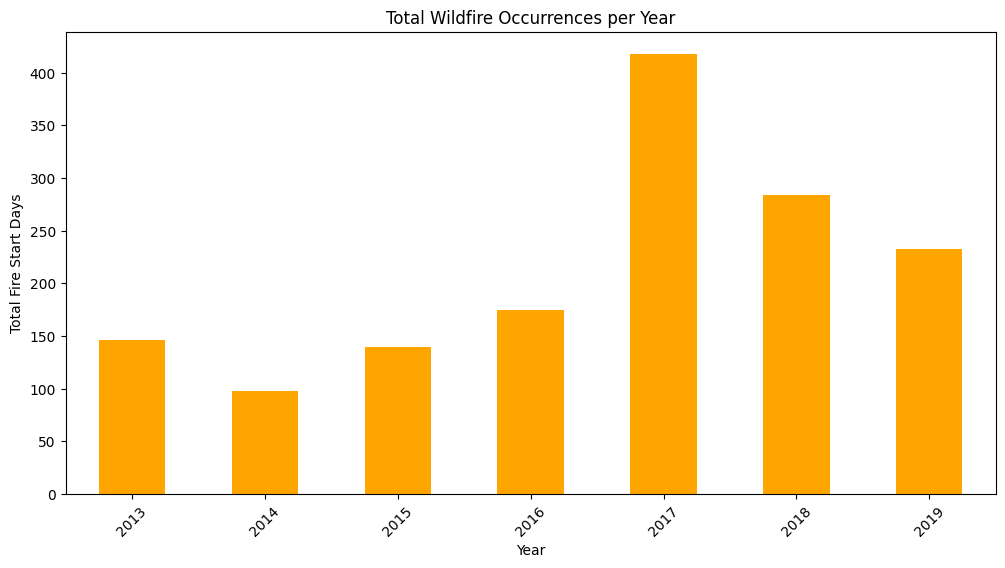

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fire_per_year = CALWILDEFIRE.groupby('YEAR')['FIRE_START_DAY'].sum()
plt.figure(figsize=(12, 6))
fire_per_year.plot(kind='bar', color='orange')
plt.xlabel('Year')
plt.ylabel('Total Fire Start Days')
plt.title('Total Wildfire Occurrences per Year')
plt.xticks(rotation=45)
plt.show()

The bar graph entitled Total Wildfire Occurrences per Year shows the California wildfire ignition days from 2013 to 2019. The data show a steep rise in 2017, at over 400 ignition days, the highest reported during the observed period. The subsequent years decrease, although 2018 also registered increased fire activities. The earlier years (2013-2016) exhibit fairly steady fire occurrences.


**Total Wildfire Start Days by Season**

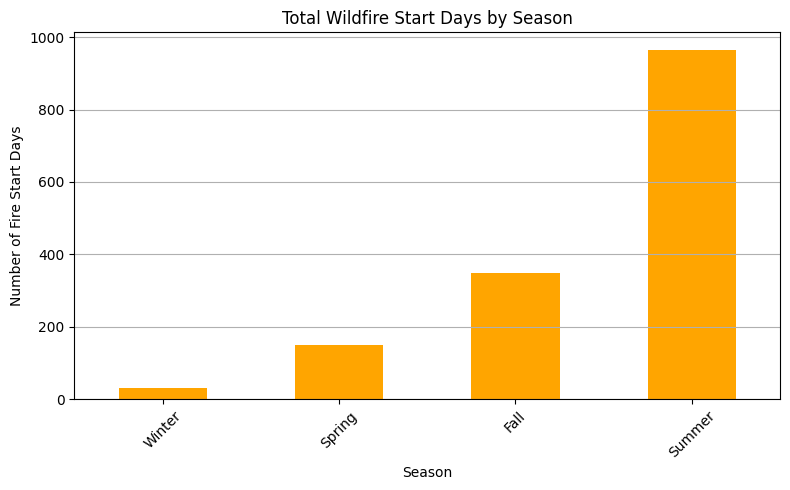

In [ ]:
seasonal_fire_counts = CALWILDEFIRE.groupby("SEASON")["FIRE_START_DAY"].sum().sort_values()
plt.figure(figsize=(8, 5))
seasonal_fire_counts.plot(kind='bar', color='orange')
plt.title("Total Wildfire Start Days by Season")
plt.xlabel("Season")
plt.ylabel("Number of Fire Start Days")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

"Total Wildfire Start Days by Season" is a bar chart that shows the distribution of wildfire start days in California by season. With almost 2,500 fire start days, summer has by far the most, followed by autumn and spring, while winter has the fewest. Given the summer's tendency toward heat, low humidity, and dry vegetation—all of which aid in the start and spread of fires—this kind of seasonal distribution makes sense.Understanding seasonal fire patterns is essential for planning and prediction models. Given the significant impact that season has on fire occurrence, the visualization bolsters the claim that season need to be used as a fundamental feature in machine learning algorithms.

Distribution of Precipitation on Fire vs Non-Fire Days

<ipython-input-15-28b6a413dd76>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=CALWILDEFIRE['FIRE_START_DAY'], y=CALWILDEFIRE['PRECIPITATION'], palette='Set2')


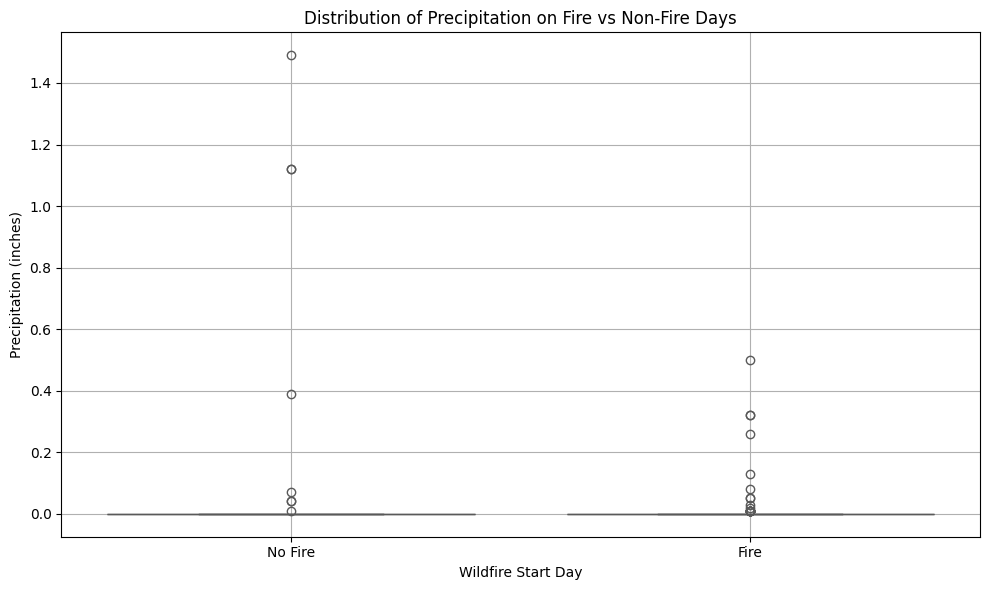

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=CALWILDEFIRE['FIRE_START_DAY'], y=CALWILDEFIRE['PRECIPITATION'], palette='Set2')
plt.xticks([0, 1], ['No Fire', 'Fire'])
plt.xlabel("Wildfire Start Day")
plt.ylabel("Precipitation (inches)")
plt.title("Distribution of Precipitation on Fire vs Non-Fire Days")
plt.grid(True)
plt.tight_layout()
plt.show()

The precipitation pattern on days with wildfire ignitions and those without is displayed in the revised boxplot for California. It makes it very evident that days when wildfires begin are closely associated with little to no precipitation. Precipitation observations are tightly clustered around 0 on the days when fires actually happened, with very few outliers showing detectable rainfall.This figure supports the inclusion of precipitation as a significant predictive variable in machine learning algorithms and emphasizes the importance of dryness in the cause of wildfires.

**Total Acres Burned by County**

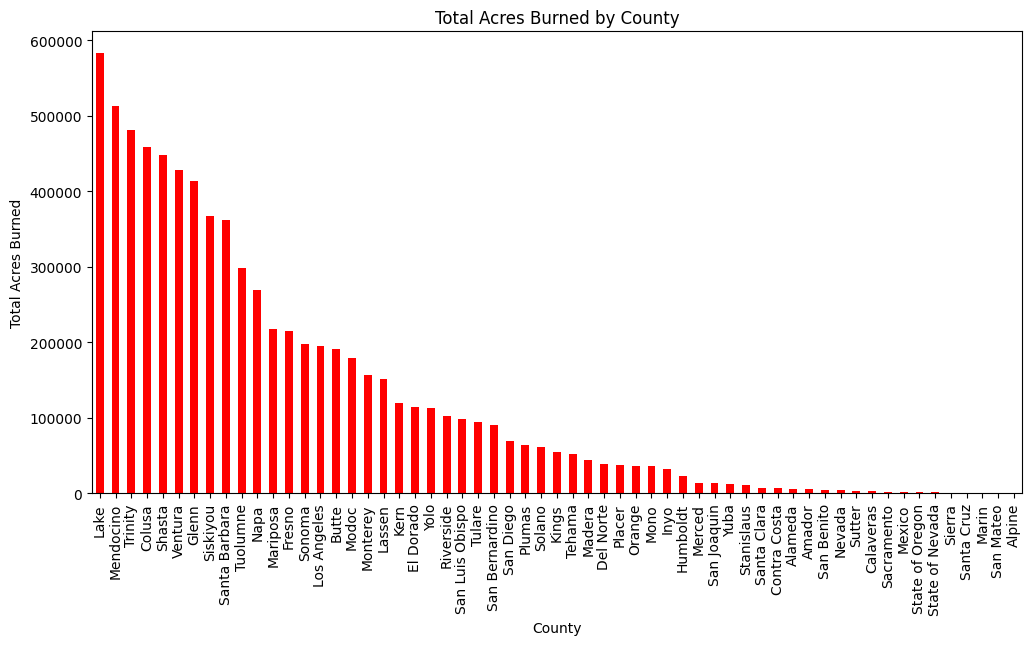

In [ ]:
acres_burned_by_county = CALWILDEFIRE.groupby('Counties')['AcresBurned'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
acres_burned_by_county.plot(kind='bar', color='red')
plt.xlabel('County')
plt.ylabel('Total Acres Burned')
plt.title('Total Acres Burned by County')
plt.xticks(rotation=90)
plt.show()

From the above plot we can identify the counties where most of the damage have happend. Which helps us to tell that particulat counties are in High risk-Zone.

**Wildfire Acres Burned by County in California (Latitude/Longitude)**

In [ ]:
import pandas as pd
import plotly.express as px
data = FINALDATA.copy()
# ...Drop rows where Latitude, Longitude, or AcresBurned is missing
data = data.dropna(subset=['Latitude', 'Longitude', 'AcresBurned'])
# ...Ensure Latitude and Longitude are numeric
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')
# ...Filtering data for California
data = data[(data['Latitude'].between(32, 42)) & (data['Longitude'].between(-125, -114))]
# ...Ploting Scatter Mapbox
fig = px.scatter_mapbox(
    data,
    lat='Latitude',
    lon='Longitude',
    color='AcresBurned',
    size='AcresBurned',
    color_continuous_scale='Reds',
    size_max=15,
    zoom=5,
    hover_name='Counties',
    hover_data={'AcresBurned': True, 'Latitude': False, 'Longitude': False}
)

fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 36.7783, "lon": -119.4179},
    mapbox_zoom=5,
    title="Wildfire Acres Burned by County in California (Latitude/Longitude)"
)

fig.show()

The map illustrates the distribution of wildfire acres burned across various counties in California, using Latitude and Longitude for precise location. Denser colors represent areas of heavy fire damage, with Chico, Sacramento, and San Bernardino having major hotspots. These locations exhibit significantly larger area burned, indicating intense wildfire activity. The map emphasizes the importance of spatial analysis in forecasting wildfires because identifying high-risk zones enables targeted prevention and mitigation. The incorporation of geographic information in predictive models enhances accuracy by correlating fire occurrences with environmental conditions, thus enabling anticipatory measures in regions vulnerable to catastrophic wildfires.


---

# CLASSIFICATION

Random Forest Classifier was chosen due to its robustness in handling class imbalance, missing data, and outliers. It is capable of identifying complex, non-linear patterns in weather and wildfire data, enhancing prediction accuracy. And its  Furthermore, its ensemble structure eliminates overfitting without loss of model interpretability, which makes it compatible with the dataset's heterogeneous weather patterns and geographic variability.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = FINALDATA.copy()
# ...Checking for missing values in 'FIRE_START_DAY' and drop them
data = data.dropna(subset=['FIRE_START_DAY'])
data = data.dropna()
# ...Verify data shape after dropping missing values
print(f"Data shape after dropping missing values: {data.shape}")
print(f"Unique values in 'FIRE_START_DAY': {data['FIRE_START_DAY'].unique()}")
# ...Convert categorical column 'SEASON' to dummy variables if present
if 'SEASON' in data.columns:
    data = pd.get_dummies(data, columns=['SEASON'], drop_first=True)
# ...Drop datetime columns to avoid type conversion errors
datetime_columns = data.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
print(f"Datetime columns found: {datetime_columns}")
data = data.drop(columns=datetime_columns, errors='ignore')
# ...Drop any remaining 'DATE' or 'Started' columns to avoid issues
data = data.drop(['DATE', 'Started'], axis=1, errors='ignore')
# ...Defineing features and target variable
X = data.drop(['FIRE_START_DAY'], axis=1, errors='ignore')
y = data['FIRE_START_DAY']

Data shape after dropping missing values: (1630, 20)
Unique values in 'FIRE_START_DAY': [ True False]
Datetime columns found: []


Preprocessing steps ensure data integrity and model readiness by handling missing values, converting categorical variable (SEASON) to dummy variables, and removing unnecessary date columns. Target variable FIRE_START_DAY is defined, and the remaining dataset is divided into features (X) and target (y). This step avoids data leakage, standardizes data types, and prepares the dataset for classification. Further, duplicate columns (DATE, Started) are removed to handle only predictive features relevant to the occurrence of wildfires.


Accuracy: 0.9202453987730062
ROC AUC: 0.8971262232131797
Confusion Matrix:
 [[  2  25]
 [  1 298]]
Classification Report:
               precision    recall  f1-score   support

       False       0.67      0.07      0.13        27
        True       0.92      1.00      0.96       299

    accuracy                           0.92       326
   macro avg       0.79      0.54      0.55       326
weighted avg       0.90      0.92      0.89       326



<Figure size 800x600 with 0 Axes>

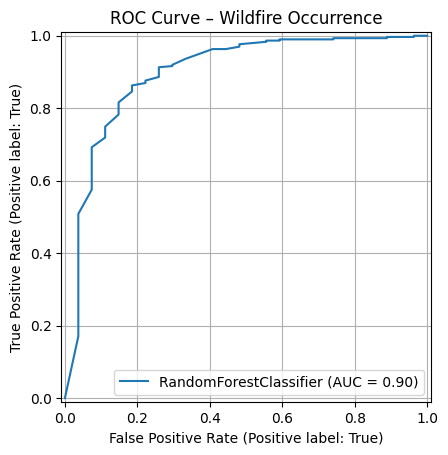

In [ ]:
# ...Check for remaining object columns and convert to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')
# ...Check for empty dataset
if X.empty or y.empty:
    print("Dataset is empty after preprocessing. Please verify data structure and preprocessing steps.")
else:
    # ...Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # ...Check for empty train/test sets
    if X_train.empty or X_test.empty:
        print("Training or testing set is empty. Adjust preprocessing steps or dataset.")
    else:
        # ...Training the Random Forest Classifier
        clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)

        # ...Predictions and Evaluation
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        # ...Calculating Metrics
        acc = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        print("Accuracy:", acc)
        print("ROC AUC:", roc_auc)
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))

        # ...Ploting ROC Curve
        plt.figure(figsize=(8, 6))
        RocCurveDisplay.from_estimator(clf, X_test, y_test)
        plt.title("ROC Curve – Wildfire Occurrence")
        plt.grid(True)
        plt.show()

The model scored 92% and an ROC AUC of 0.90, a high rate of predictive performance in detecting wildfire events. The confusion matrix shows that the model accurately predicted 298 days of wildfires (True) but not for non-wildfire days (False), with only 2 correct predictions and 25 false alarms. The classification report shows precision of 0.92for wildfire days but only 0.67for non-wildfire days, which represents class imbalance. The ROC curve also determines the model's ability to differentiate between classes with a satisfactory true positive rate and low false positive rate.



# CLUSTERING

The reason K-Means clustering is employed is that it is computationally easy and simple to interpret, making it suitable for identifying high-risk wildfire regions based on similar fire patterns. The numerical and spatial character of the data (Latitude, Longitude) is well suited to K-Means, allowing for effective clustering of wildfire events by region burned. K-Means is also scalable and can effectively handle large datasets, providing a simple model for partitioning areas according to wildfire severity without sacrificing simplicity and interpretability.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
data = FINALDATA.copy()
data = data.dropna()

# ...Converting 'SEASON' column to dummy variables if present
if 'SEASON' in data.columns:
    data = pd.get_dummies(data, columns=['SEASON'], drop_first=True)

# ...Droping datetime columns to avoid conversion issues
datetime_columns = data.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns.tolist()
data = data.drop(columns=datetime_columns, errors='ignore')

# ...Droping 'DATE' and 'Started' columns if present
data = data.drop(['DATE', 'Started'], axis=1, errors='ignore')

# ...Defineing features
X = data.drop(['AcresBurned'], axis=1, errors='ignore')

# ...Convert object columns to numeric
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = pd.to_numeric(X[col], errors='coerce')

# ....Impute missing values in the feature set using the median strategy
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ...Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning:

Skipping features without any observed values: ['Status' 'Counties']. At least one non-missing value is needed for imputation with strategy='median'.



Preprocessing involves duplicating the dataset, deleting missing values, and converting categorical features (SEASON) into dummy variables. Datetime features and irrelevant date-related features (DATE, Started) are dropped. Numerical conversion of object-type features is followed by imputation using the median strategy to handle missing values. Scaling data using StandardScaler standardizes features to have a mean of 0 and standard deviation of 1, which makes feature importance consistent and improves model performance, especially for clustering models.


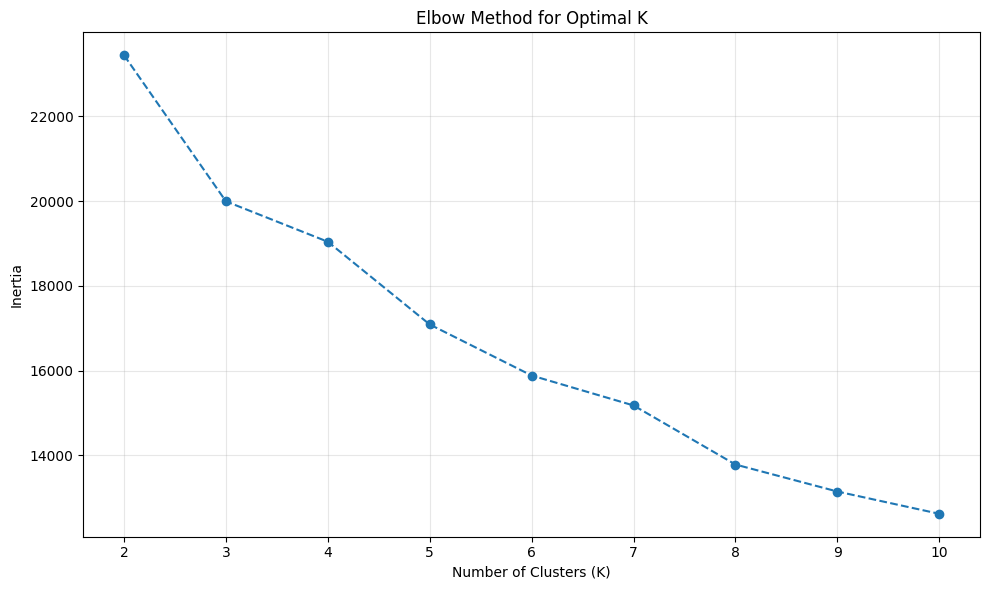

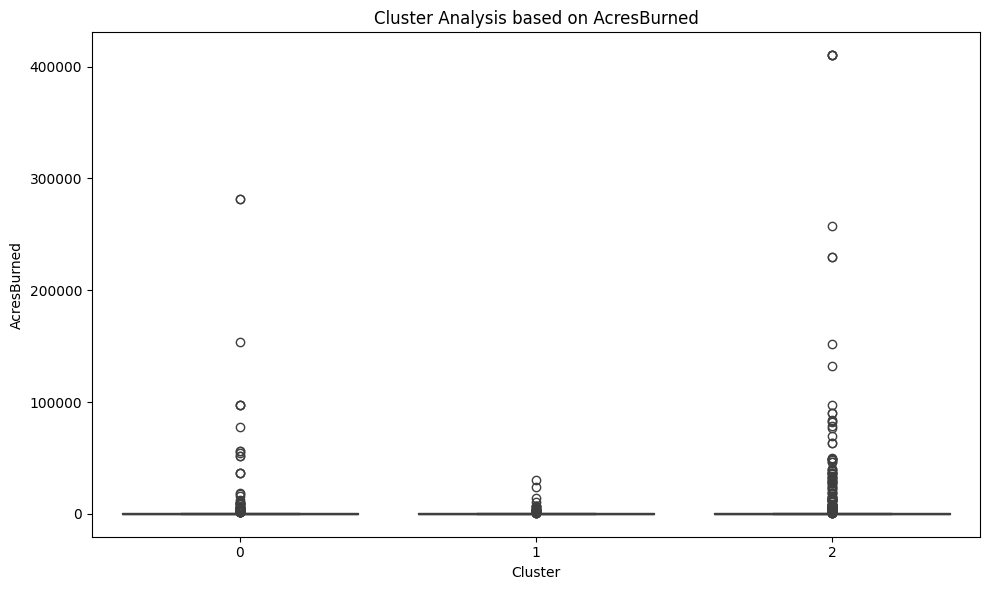

Silhouette Score for 3 clusters: 0.3054909808750101

Cluster Counts:
 Cluster
2    1063
0     364
1     203
Name: count, dtype: int64


In [ ]:
# ...Determineing optimal number of clusters using the Elbow Method
inertia = []
range_n_clusters = range(2, 11)
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ...Applying K-Means with the optimal number of clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ...Adding cluster labels to the original data
data['Cluster'] = clusters

# ...Analyzeing clusters based on AcresBurned
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='AcresBurned', data=data)
plt.title('Cluster Analysis based on AcresBurned')
plt.xlabel('Cluster')
plt.ylabel('AcresBurned')
plt.tight_layout()
plt.show()
silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for {optimal_k} clusters: {silhouette_avg}")
print("\nCluster Counts:\n", data['Cluster'].value_counts())


The elbow method plot suggests that the optimal number of clusters is **3**, as the curve begins to flatten at this point. The silhouette score of **0.305** indicates moderate cluster separation but suggests potential overlap among clusters. The boxplot reveals that all three clusters have a significant number of outliers with extremely high AcresBurned, indicating variability within clusters. Cluster 2 contains the most data points (1063), while Clusters 0 and 1 have **364** and **203** data points, respectively, suggesting an imbalance in cluster sizes.


In [ ]:
import plotly.express as px

# ...Applying K-Means with the optimal number of clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ...Adding cluster labels to the original data
data['Cluster'] = clusters


if 'Latitude' in data.columns and 'Longitude' in data.columns:
    # ...Ploting the clusters using Latitude and Longitude
    fig = px.scatter_mapbox(
        data,
        lat='Latitude',
        lon='Longitude',
        color='Cluster',
        color_continuous_scale='Viridis',
        size='AcresBurned',
        size_max=15,
        zoom=5,
        hover_name='Cluster',
        hover_data={'AcresBurned': True, 'Latitude': False, 'Longitude': False}
    )

    fig.update_layout(
        mapbox_style="carto-positron",
        mapbox_center={"lat": 36.7783, "lon": -119.4179},
        mapbox_zoom=5,
        title="Wildfire Clusters in California (Based on Latitude and Longitude)"
    )

    fig.show()
else:
    print("Latitude and Longitude columns are not available in the dataset.")


The map displays the spatial pattern of wildfire clusters in California by Latitude and Longitude, where cluster membership was determined by K-Means clustering. The color ramp (Viridis) shows the cluster labels 0 to 2, which correspond to different wildfire severity zones:

Cluster 0 (Purple):

Concentrated in the southern regions, particularly in San Bernardino and Lancaster.

Indicates relatively moderate wildfire activity with a mix of lower and higher acreage burned.

Cluster 1 (Yellow):

Scattered in central and northern regions, with some regions near Sacramento and Chico.

These are regions of more severe wildfire outbreaks, as corroborated by larger marker sizes that correspond to higher AcresBurned.

Cluster 2 (Green):

Spread primarily along the north coast and central parts of California.

Characterized by less severe fires and smaller marker sizes, indicating fewer instances of wildfires.

---
---

# Conclusion



The objective of this project was to analyze wildfire occurrences in California and identify high-risk zones based on weather patterns, fire-related incidents, and geographic factors. The analysis utilized the CA Weather Fire Dataset and the California Fire Incidents Dataset to detect patterns in wildfire start days and the extent of acres burned through classification and clustering methods.

The classification task aimed to predict wildfire start days based on weather conditions, including precipitation, temperature, wind speed, and temperature range. A Random Forest Classifier was trained to classify fire start days, achieving a high overall accuracy of 92%. However, the model exhibited significant class imbalance, performing exceptionally well in identifying wildfire days (recall: 1.00, F1-score: 0.96) but poorly in identifying non-fire days (recall: 0.07, F1-score: 0.13). The strong bias towards predicting fire days suggests that the model heavily prioritizes the majority class, reducing its reliability in detecting non-fire days. Visualizations, such as bar plots of fire start days by year and seasonal comparisons, illustrated the variability in wildfire occurrences. Additionally, a boxplot analysis revealed that dry conditions were more common on fire start days, indicating that precipitation could be a critical predictor.

In the clustering analysis, the K-Means algorithm was applied to identify distinct wildfire patterns based on weather parameters and geographic location. The optimal number of clusters was determined as three, with a silhouette score of 0.305, indicating weak cluster separation and overlap among clusters. Cluster 2, comprising 1063 records, was the largest and likely represented more frequent or widespread fire incidents. Cluster 0 had 364 records, while Cluster 1 contained 203 records, suggesting some degree of variation in fire behavior or geographic distribution. However, the low silhouette score implies that the clustering structure is not well-defined, and further refinement, such as exploring additional clustering techniques or feature engineering, may be necessary.

Several limitations and assumptions affected the analysis. Mean imputation was applied to handle missing data, potentially introducing biases, especially in precipitation and wind speed data. Additionally, the datasets varied in temporal scope, limiting full alignment between weather and incident data. The model's strong bias towards predicting fire days may necessitate further adjustments, such as resampling or implementing class weight adjustments. Additionally, the clustering analysis exhibited weak separation, indicating a need for more robust clustering methods or additional features to enhance interpretability.

Overall, the project successfully demonstrated the potential of weather and incident data in identifying wildfire risk patterns. While the model effectively identified fire days, the imbalance in class performance and weak cluster separation indicate areas for further refinement to improve predictive accuracy and cluster differentiation.
